In [1]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
import sklearn


path = "daily_food_nutrition_dataset.csv"
data = pandas.read_csv(path, on_bad_lines='skip')


In [2]:
print(data.describe())

       Calories (kcal)  Protein (g)  Carbohydrates (g)     Fat (g)  \
count       645.000000   645.000000         645.000000  645.000000   
mean        146.294574     6.300620          15.435194    6.469612   
std         139.984360     8.782683          16.349230    8.142916   
min           0.000000     0.000000           0.000000    0.000000   
25%          42.000000     0.500000           1.300000    0.200000   
50%         105.000000     2.700000           9.200000    3.000000   
75%         200.000000     7.000000          27.000000   10.000000   
max         680.000000    45.000000          70.000000   40.000000   

        Fiber (g)  Sugars (g)  Sodium (mg)  Cholesterol (mg)  \
count  645.000000  645.000000   645.000000        645.000000   
mean     1.702481    5.294264   246.331783         20.482171   
std      2.121275    8.537343   308.472431         43.560072   
min      0.000000    0.000000     0.000000          0.000000   
25%      0.000000    0.400000     5.000000       

In [3]:
data.head()

,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.0,2.0,14.0,0.0,1.0,180,370,Breakfast,250
1,Whole Wheat Toast (1 slice),Grain,80,4.0,14.0,1.0,2.0,2.0,140,0,Breakfast,0
2,Coffee (black),Beverage,5,0.3,0.0,0.1,0.0,0.0,5,0,Breakfast,0
3,Banana,Fruit,105,1.3,27.0,0.4,3.1,14.0,1,0,Breakfast,0
4,Grilled Chicken Salad,Meal/Protein,350,30.0,10.0,20.0,5.0,4.0,400,80,Lunch,500


In [4]:
df = data[["Food_Item", "Calories (kcal)", "Protein (g)", "Carbohydrates (g)", "Fat (g)", "Sugars (g)", "Sodium (mg)"]]
head = df.head()
print(head)

                     Food_Item  Calories (kcal)  Protein (g)  \
0     Scrambled Eggs (2 large)              180         12.0   
1  Whole Wheat Toast (1 slice)               80          4.0   
2               Coffee (black)                5          0.3   
3                       Banana              105          1.3   
4        Grilled Chicken Salad              350         30.0   

   Carbohydrates (g)  Fat (g)  Sugars (g)  Sodium (mg)  
0                2.0     14.0         1.0          180  
1               14.0      1.0         2.0          140  
2                0.0      0.1         0.0            5  
3               27.0      0.4        14.0            1  
4               10.0     20.0         4.0          400  


# EDA — 6 Nutrients for Dietitian System ML

**Goal:** Understand the distribution, relationships, and structure of the 6 nutrient features to inform ML approach.

In [5]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# The 6 nutrients we care about
nutrients = ["Calories (kcal)", "Protein (g)", "Carbohydrates (g)", "Fat (g)", "Sugars (g)", "Sodium (mg)"]
df_nutrients = df[nutrients].copy()

print("Shape:", df_nutrients.shape)
print("\nMissing values:\n", df_nutrients.isnull().sum())
print("\nStats:\n", df_nutrients.describe().round(2))

Shape: (645, 6)

Missing values:
 Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Sugars (g)           0
Sodium (mg)          0
dtype: int64

Stats:
        Calories (kcal)  Protein (g)  Carbohydrates (g)  Fat (g)  Sugars (g)  \
count           645.00       645.00             645.00   645.00      645.00   
mean            146.29         6.30              15.44     6.47        5.29   
std             139.98         8.78              16.35     8.14        8.54   
min               0.00         0.00               0.00     0.00        0.00   
25%              42.00         0.50               1.30     0.20        0.40   
50%             105.00         2.70               9.20     3.00        2.00   
75%             200.00         7.00              27.00    10.00        6.00   
max             680.00        45.00              70.00    40.00       60.00   

       Sodium (mg)  
count       645.00  
mean        246.33  
std         308.47  
min       

## 1. Distributions — how is each nutrient spread?

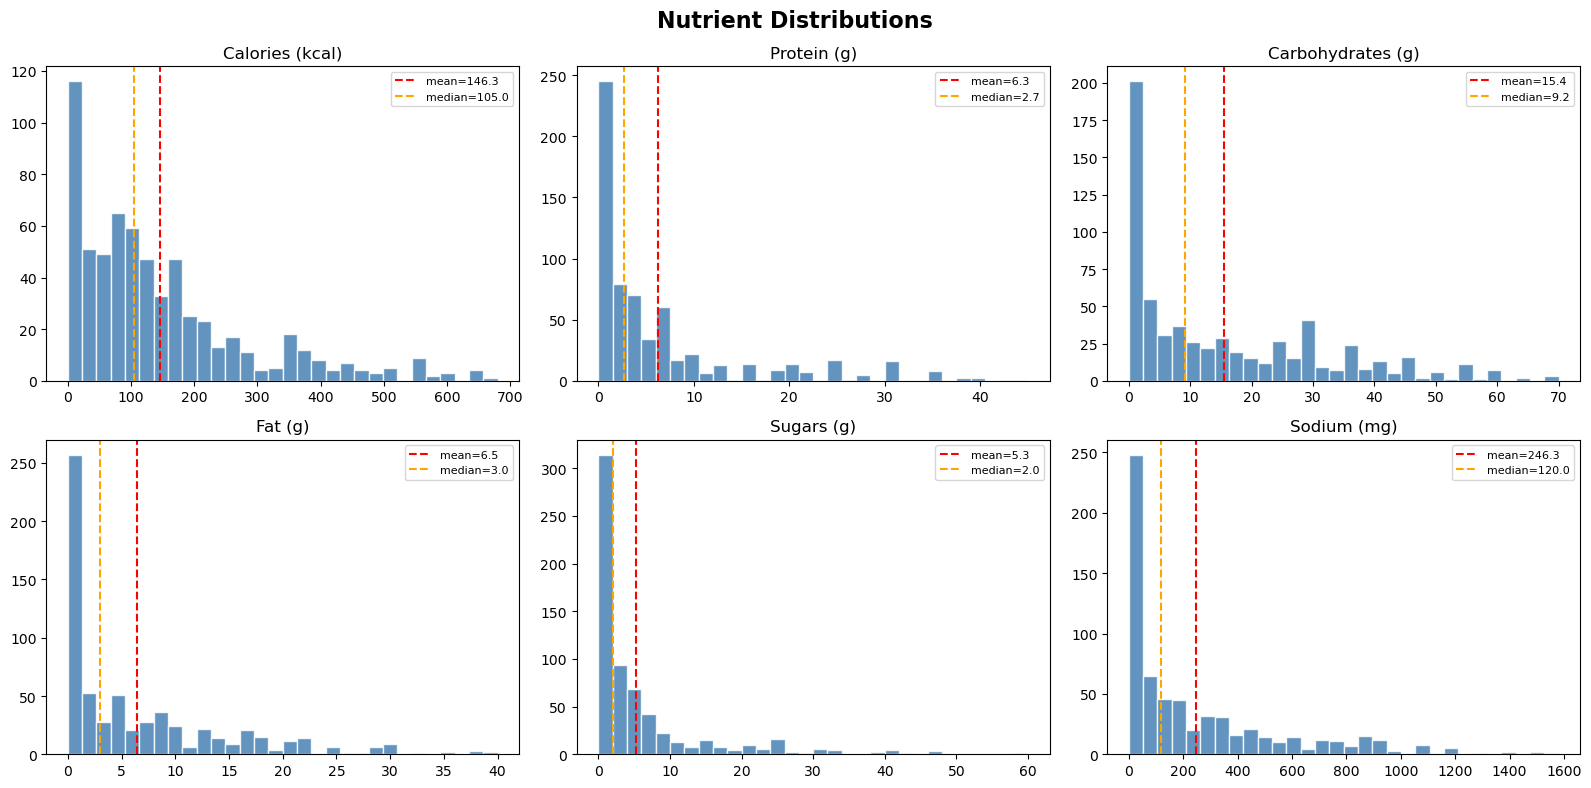

Skewness (>1 = right-skewed, may need log transform):
Calories (kcal)      1.44
Protein (g)          1.95
Carbohydrates (g)    1.05
Fat (g)              1.58
Sugars (g)           2.62
Sodium (mg)          1.57
dtype: float64


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Nutrient Distributions", fontsize=16, fontweight='bold')

for ax, col in zip(axes.flat, nutrients):
    ax.hist(df_nutrients[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df_nutrients[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f"mean={df_nutrients[col].mean():.1f}")
    ax.axvline(df_nutrients[col].median(), color='orange', linestyle='--', linewidth=1.5, label=f"median={df_nutrients[col].median():.1f}")
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Skewness — important for ML preprocessing decisions
print("Skewness (>1 = right-skewed, may need log transform):")
print(df_nutrients.skew().round(2))

## 2. Outliers — boxplots per nutrient

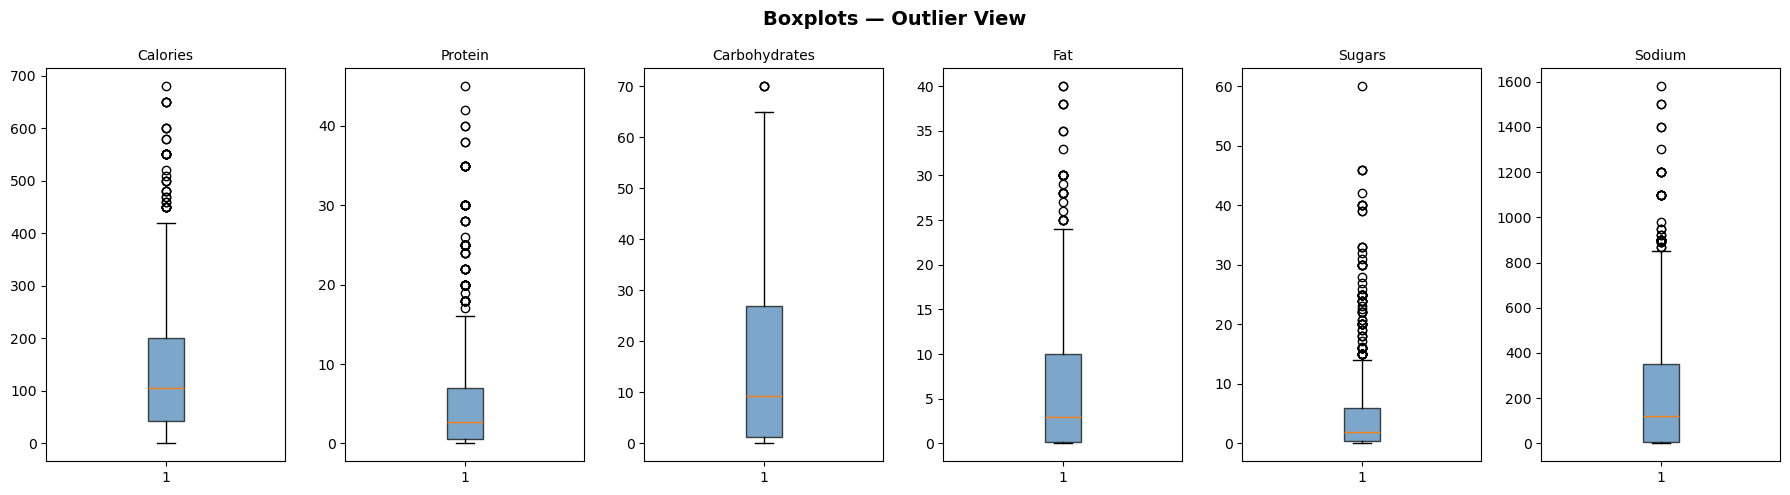

Outlier counts (IQR method):
  Calories (kcal): 38 outliers (5.9%)
  Protein (g): 84 outliers (13.0%)
  Carbohydrates (g): 3 outliers (0.5%)
  Fat (g): 30 outliers (4.7%)
  Sugars (g): 82 outliers (12.7%)
  Sodium (mg): 39 outliers (6.0%)


In [7]:
fig, axes = plt.subplots(1, 6, figsize=(18, 5))
fig.suptitle("Boxplots — Outlier View", fontsize=14, fontweight='bold')

for ax, col in zip(axes, nutrients):
    ax.boxplot(df_nutrients[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax.set_title(col.split(" ")[0], fontsize=10)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

# Count outliers (IQR method) per nutrient
print("Outlier counts (IQR method):")
for col in nutrients:
    q1, q3 = df_nutrients[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_nutrients[col] < q1 - 1.5*iqr) | (df_nutrients[col] > q3 + 1.5*iqr)).sum()
    print(f"  {col}: {n_out} outliers ({n_out/len(df_nutrients)*100:.1f}%)")

## 3. Correlation — which nutrients move together?

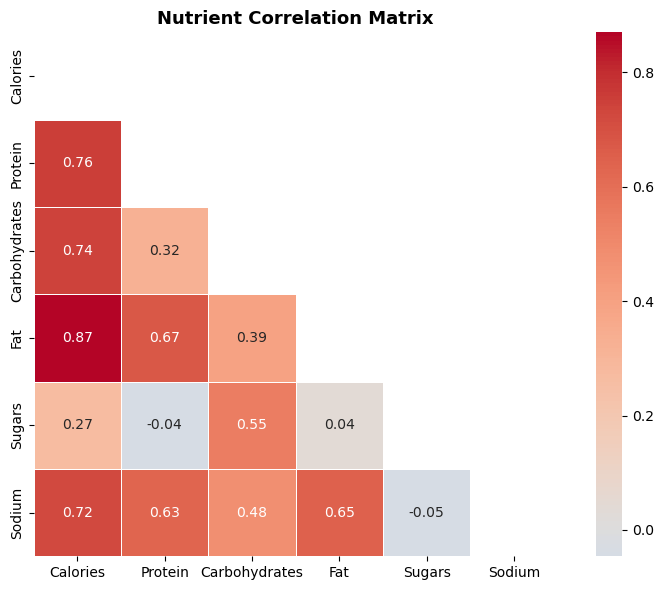

In [8]:
corr = df_nutrients.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True,
            xticklabels=[c.split(" ")[0] for c in nutrients],
            yticklabels=[c.split(" ")[0] for c in nutrients])
ax.set_title("Nutrient Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Pairplot — scatter relationships between all pairs

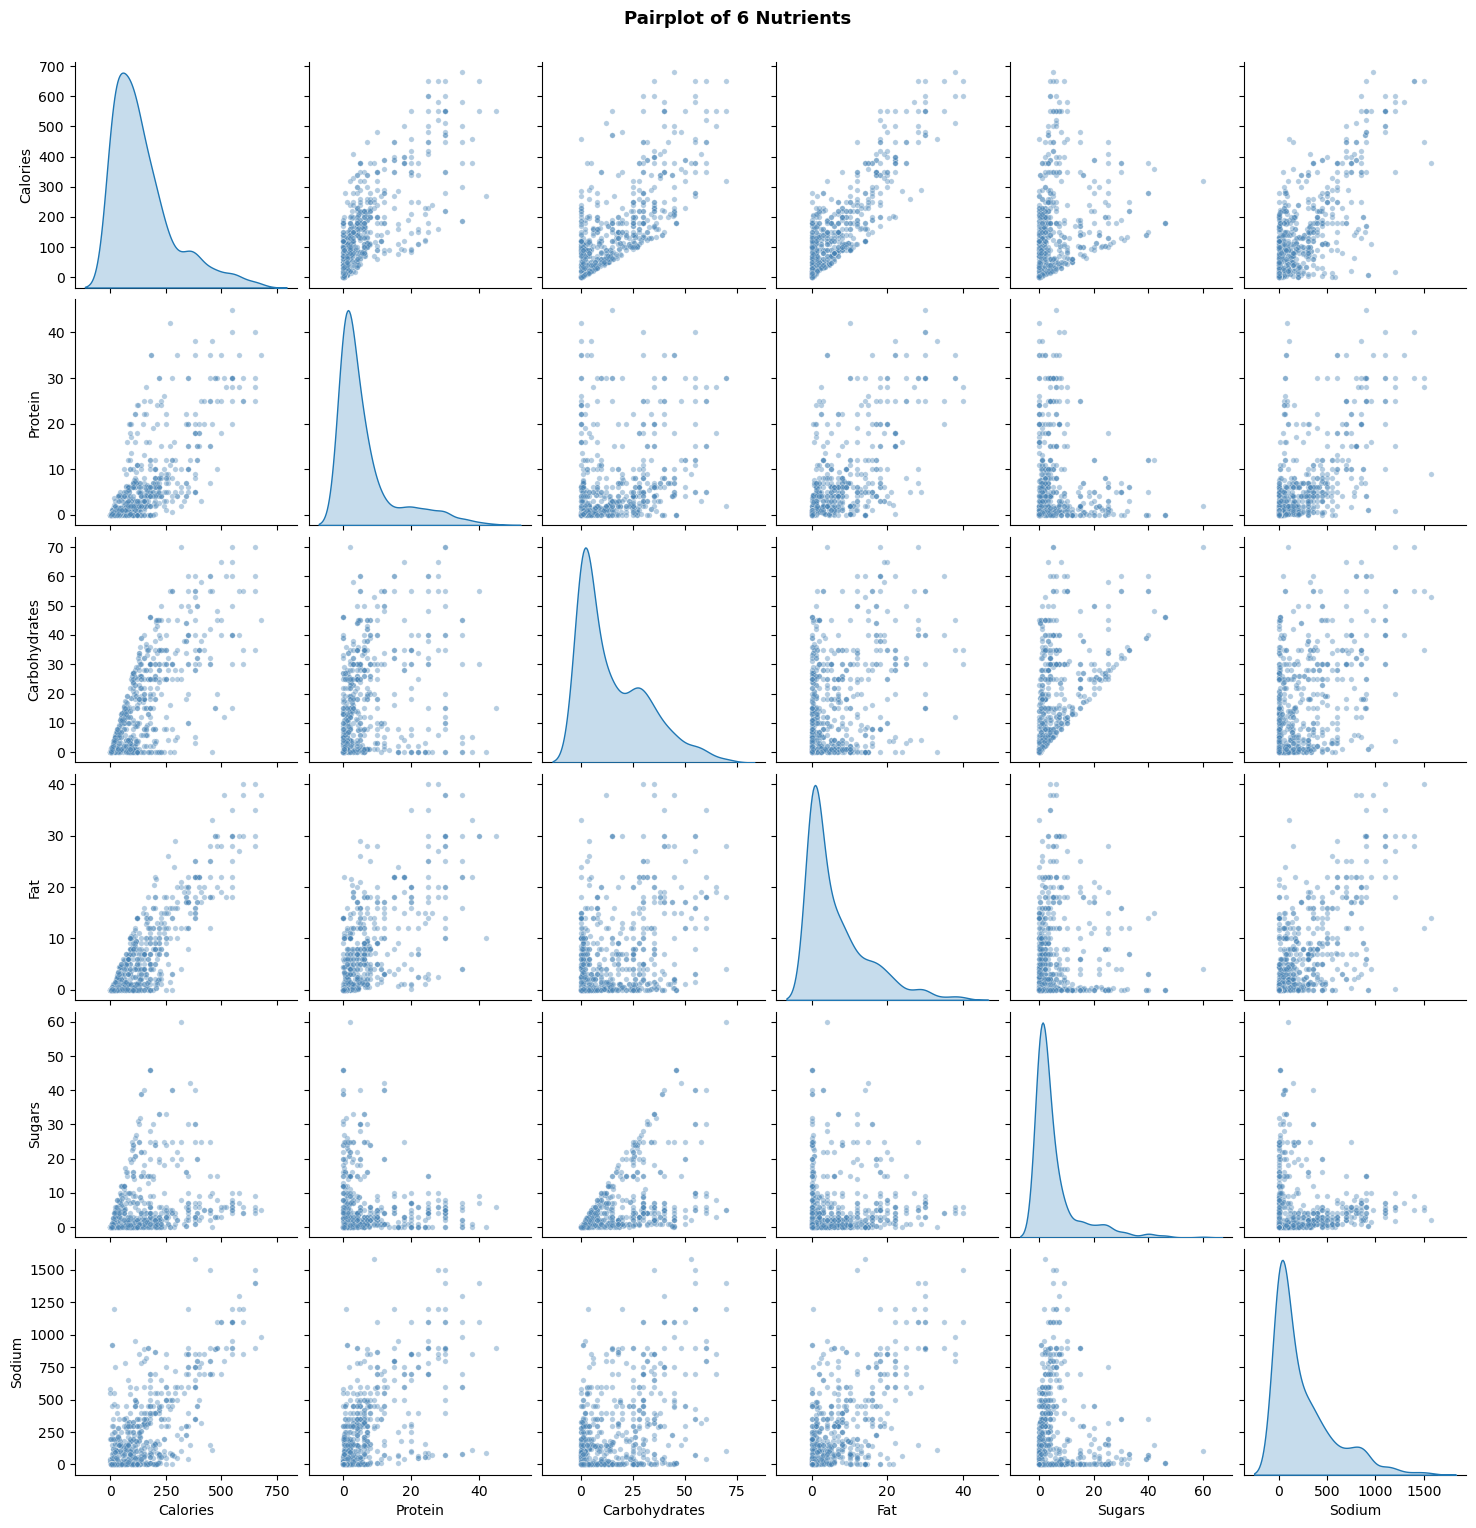

In [9]:
short_names = {c: c.split(" ")[0] for c in nutrients}
df_plot = df_nutrients.rename(columns=short_names)

pg = sns.pairplot(df_plot, diag_kind="kde", plot_kws=dict(alpha=0.4, s=15, color='steelblue'))
pg.figure.suptitle("Pairplot of 6 Nutrients", y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 5. Category breakdown — nutrient profiles by food group

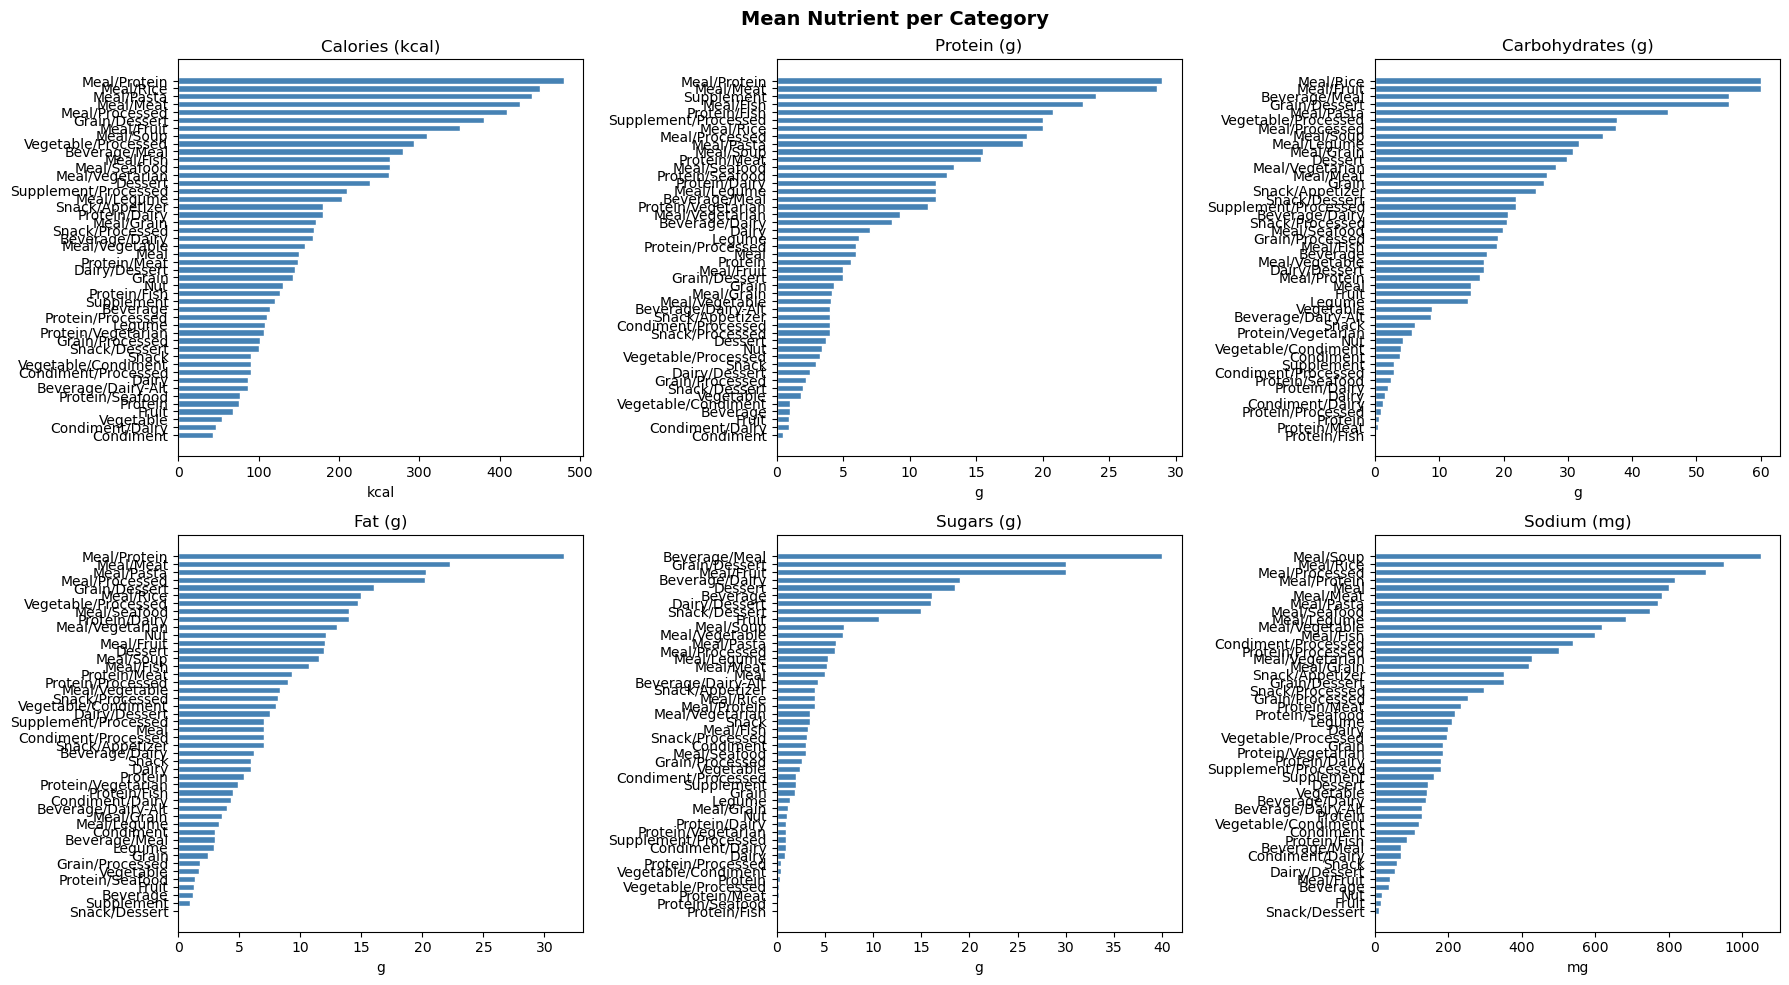


Category item counts:
Category
Condiment               120
Vegetable                70
Grain                    59
Beverage                 54
Fruit                    34
Protein/Meat             31
Meal/Processed           30
Dairy                    27
Dessert                  27
Meal/Meat                20
Meal/Pasta               16
Snack/Processed          16
Nut                      14
Legume                   11
Meal/Vegetarian          10
Protein/Fish              9
Meal/Vegetable            9
Grain/Processed           8
Protein/Vegetarian        8
Meal/Seafood              7
Condiment/Dairy           6
Meal/Protein              5
Protein/Seafood           5
Meal/Grain                5
Protein                   4
Meal/Soup                 4
Meal/Legume               3
Meal/Fish                 3
Vegetable/Processed       3
Beverage/Dairy            3
Beverage/Dairy-Alt        3
Beverage/Meal             2
Vegetable/Condiment       2
Grain/Dessert             2
Protein/Processe

In [10]:
df_full = data[["Category"] + nutrients].copy()
cat_means = df_full.groupby("Category")[nutrients].mean().round(1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Mean Nutrient per Category", fontsize=14, fontweight='bold')

colors = plt.cm.tab10.colors
for ax, col in zip(axes.flat, nutrients):
    vals = cat_means[col].sort_values(ascending=True)
    ax.barh(vals.index, vals.values, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col.split("(")[1].replace(")", "") if "(" in col else "")

plt.tight_layout()
plt.show()

print("\nCategory item counts:")
print(data["Category"].value_counts())

## 6. PCA — can we reduce 6D to 2D and still see structure?

This tells us if the 6 nutrients have a natural lower-dimensional structure useful for clustering or visualization.

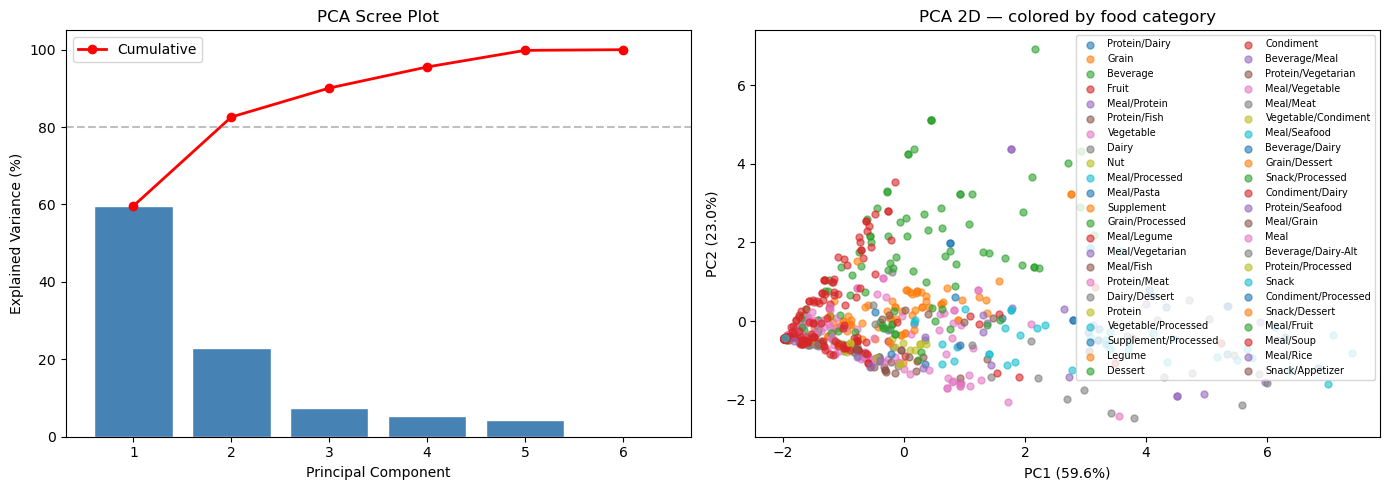


Variance explained by 2 PCs: 82.6%
Variance explained by 3 PCs: 90.1%


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_nutrients.fillna(0))

pca = PCA(n_components=6)
pca.fit(X_scaled)
explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 7), explained * 100, color='steelblue', edgecolor='white')
axes[0].plot(range(1, 7), np.cumsum(explained) * 100, 'ro-', linewidth=2, label='Cumulative')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("PCA Scree Plot")
axes[0].legend()
axes[0].axhline(80, color='gray', linestyle='--', alpha=0.5)

# 2D projection colored by category
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)
categories = data["Category"].fillna("Unknown")
unique_cats = categories.unique()
palette = plt.cm.tab10.colors

for i, cat in enumerate(unique_cats):
    mask = categories == cat
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    label=cat, alpha=0.6, s=25, color=palette[i % len(palette)])

axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[1].set_title("PCA 2D — colored by food category")
axes[1].legend(fontsize=7, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

print(f"\nVariance explained by 2 PCs: {sum(explained[:2])*100:.1f}%")
print(f"Variance explained by 3 PCs: {sum(explained[:3])*100:.1f}%")

## 7. K-Means elbow — how many natural clusters exist in the 6D space?

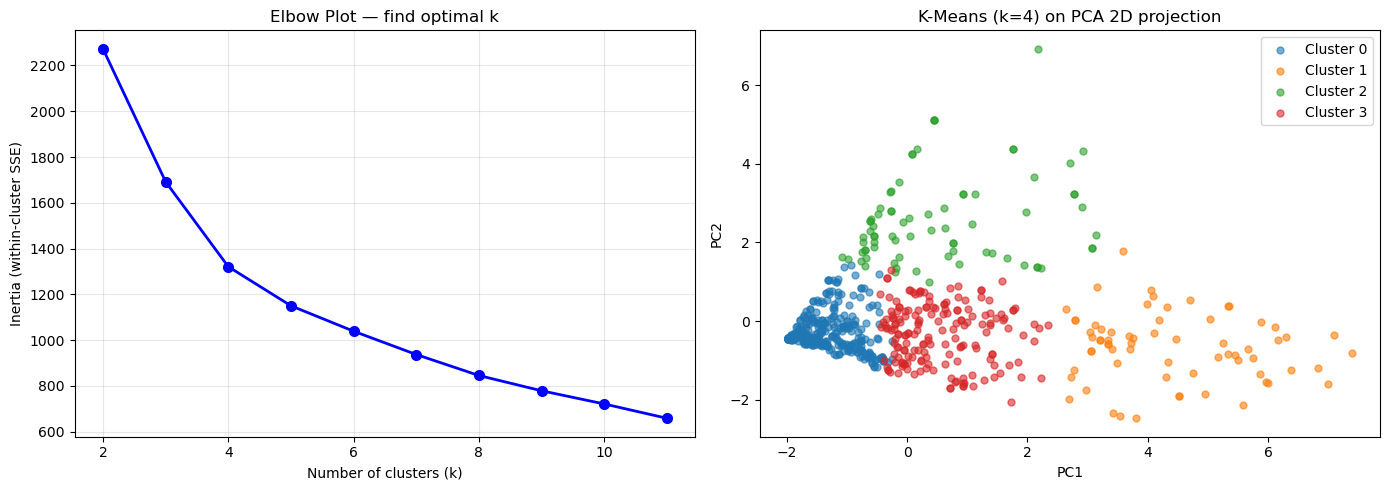


Cluster means (nutrients):
         Calories (kcal)  Protein (g)  Carbohydrates (g)  Fat (g)  Sugars (g)  \
cluster                                                                         
0                   48.7          1.8                4.6      2.4         2.1   
1                  461.2         24.4               37.3     23.4         5.7   
2                  204.1          3.1               33.2      6.3        25.2   
3                  181.4          9.1               19.5      7.7         2.4   

         Sodium (mg)  
cluster               
0               93.5  
1              888.5  
2               95.9  
3              348.4  


In [12]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 12)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow Plot — find optimal k")
axes[0].grid(alpha=0.3)

# Show k=4 clusters on PCA 2D
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = km4.fit_predict(X_scaled)

for cluster in range(4):
    mask = labels == cluster
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    label=f"Cluster {cluster}", alpha=0.6, s=25)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("K-Means (k=4) on PCA 2D projection")
axes[1].legend()

plt.tight_layout()
plt.show()

# What does each cluster look like nutritionally?
df_clustered = df_nutrients.copy()
df_clustered["cluster"] = labels
print("\nCluster means (nutrients):")
print(df_clustered.groupby("cluster")[nutrients].mean().round(1))

## 8. Summary & ML Opportunities

Run this cell to get a data-driven summary of what we can build.

In [13]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"Dataset: {len(df_nutrients)} food items, 6 nutrients")
print()
print("KEY FINDINGS:")
skews = df_nutrients.skew()
for col in nutrients:
    s = skews[col]
    flag = " ← log-transform recommended" if s > 2 else ""
    print(f"  {col.split(' ')[0]:<15} skew={s:.1f}{flag}")

print()
print("ML OPPORTUNITIES:")
print("  1. CLUSTERING      — group foods by nutritional profile (K-Means/DBSCAN)")
print("     → assign a 'nutritional archetype' to each food item")
print()
print("  2. SIMILARITY SEARCH — the 6D nutrition_vector already stored in pgvector")
print("     → 'find foods similar to X' using cosine/L2 distance")
print()
print("  3. CATEGORY PREDICTION — classify food category from nutrients alone")
print("     → Random Forest / XGBoost on the 6 features")
print()
print("  4. MEAL BALANCING  — given a partial meal, recommend items to hit daily targets")
print("     → optimization or regression-based completion")
print()
print("PREPROCESSING NEEDED:")
high_skew = [c.split(" ")[0] for c in nutrients if skews[c] > 2]
print(f"  - Log-transform (or log1p): {', '.join(high_skew) if high_skew else 'none needed'}")
print(f"  - StandardScaler before any distance-based method (done in PCA/KMeans above)")

EDA SUMMARY
Dataset: 645 food items, 6 nutrients

KEY FINDINGS:
  Calories        skew=1.4
  Protein         skew=1.9
  Carbohydrates   skew=1.0
  Fat             skew=1.6
  Sugars          skew=2.6 ← log-transform recommended
  Sodium          skew=1.6

ML OPPORTUNITIES:
  1. CLUSTERING      — group foods by nutritional profile (K-Means/DBSCAN)
     → assign a 'nutritional archetype' to each food item

  2. SIMILARITY SEARCH — the 6D nutrition_vector already stored in pgvector
     → 'find foods similar to X' using cosine/L2 distance

  3. CATEGORY PREDICTION — classify food category from nutrients alone
     → Random Forest / XGBoost on the 6 features

  4. MEAL BALANCING  — given a partial meal, recommend items to hit daily targets
     → optimization or regression-based completion

PREPROCESSING NEEDED:
  - Log-transform (or log1p): Sugars
  - StandardScaler before any distance-based method (done in PCA/KMeans above)


---
# ML Feature Prototypes

Implementing and testing all 4 ML directions on real data.

## Feature 1: Nutritional Archetypes (Clustering)

Assign every food item a named "nutritional archetype" based on its 6-nutrient profile.
This is what we'd store alongside `nutrition_vector` in the DB.

Silhouette scores by k:
  k=2: 0.505 ← best
  k=3: 0.412
  k=4: 0.377
  k=5: 0.379
  k=6: 0.342
  k=7: 0.358
  k=8: 0.338
  k=9: 0.349


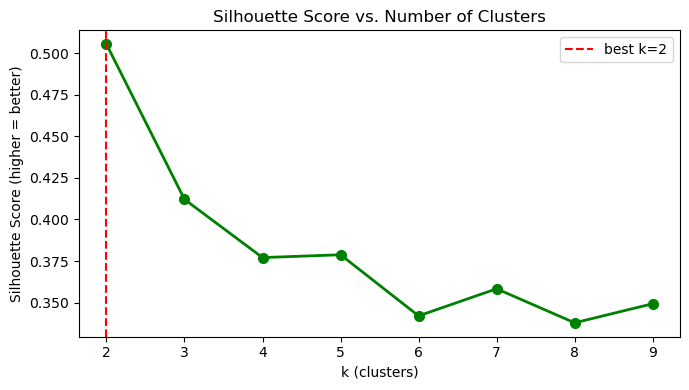

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

nutrients = ["Calories (kcal)", "Protein (g)", "Carbohydrates (g)", "Fat (g)", "Sugars (g)", "Sodium (mg)"]
df_nutrients = df[nutrients].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_nutrients)

# Find best k using silhouette score
sil_scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

best_k = max(sil_scores, key=sil_scores.get)
print("Silhouette scores by k:")
for k, s in sil_scores.items():
    marker = " ← best" if k == best_k else ""
    print(f"  k={k}: {s:.3f}{marker}")

plt.figure(figsize=(7, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), 'go-', linewidth=2, markersize=7)
plt.xlabel("k (clusters)")
plt.ylabel("Silhouette Score (higher = better)")
plt.title("Silhouette Score vs. Number of Clusters")
plt.axvline(best_k, color='red', linestyle='--', label=f"best k={best_k}")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

# Train final model with best_k and auto-name each archetype
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

df_arch = df[["Food_Item"]].copy()
df_arch[nutrients] = df_nutrients
df_arch["cluster"] = cluster_labels

# Auto-name archetypes based on dominant nutrient in cluster centroid
centroids_original = scaler.inverse_transform(km_final.cluster_centers_)
centroid_df = pd.DataFrame(centroids_original, columns=nutrients)

ARCHETYPE_NAMES = {
    "Calories (kcal)": "High-Calorie",
    "Protein (g)": "High-Protein",
    "Carbohydrates (g)": "High-Carb",
    "Fat (g)": "High-Fat",
    "Sugars (g)": "High-Sugar",
    "Sodium (mg)": "High-Sodium",
}

archetype_map = {}
for i, row in centroid_df.iterrows():
    # Normalize each nutrient by its global max so they're comparable
    normed = row / df_nutrients.max()
    dominant = normed.idxmax()
    archetype_map[i] = ARCHETYPE_NAMES[dominant]

df_arch["archetype"] = df_arch["cluster"].map(archetype_map)

print("Archetype assignments:")
for cluster_id, name in archetype_map.items():
    subset = df_arch[df_arch["cluster"] == cluster_id]
    print(f"\n  Cluster {cluster_id} → '{name}' ({len(subset)} foods)")
    print("  Centroid:", centroid_df.loc[cluster_id].round(1).to_dict())
    print("  Examples:", subset["Food_Item"].sample(min(3, len(subset)), random_state=1).tolist())

Archetype assignments:

  Cluster 0 → 'High-Calorie' (119 foods)
  Centroid: {'Calories (kcal)': 388.8, 'Protein (g)': 18.2, 'Carbohydrates (g)': 35.7, 'Fat (g)': 19.2, 'Sugars (g)': 8.6, 'Sodium (mg)': 678.9}
  Examples: ['Ceviche (1 cup fish)', 'Veal Parmesan (1 serving)', 'Hummus Wrap (large)']

  Cluster 1 → 'High-Carb' (526 foods)
  Centroid: {'Calories (kcal)': 91.4, 'Protein (g)': 3.6, 'Carbohydrates (g)': 10.9, 'Fat (g)': 3.6, 'Sugars (g)': 4.5, 'Sodium (mg)': 148.5}
  Examples: ['Egg Noodles (1 cup cooked)', 'Berry Coulis (1 tbsp)', 'Pico de Gallo (1/4 cup)']


## Feature 2: Similarity Search (mimicking pgvector cosine distance)

Given a food item, find the N most nutritionally similar foods.
In production this would be a single pgvector query: `ORDER BY nutrition_vector <=> query_vector LIMIT N`

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

# Build normalized vector matrix (same as what pgvector stores)
X_normalized = X_scaled  # already StandardScaled

def find_similar_foods(food_name, top_n=5):
    """Return top_n most nutritionally similar foods (cosine similarity on scaled 6D vector)."""
    matches = df[df["Food_Item"].str.contains(food_name, case=False)]
    if matches.empty:
        print(f"Food '{food_name}' not found.")
        return
    
    idx = matches.index[0]
    query_vec = X_normalized[idx].reshape(1, -1)
    sims = cosine_similarity(query_vec, X_normalized)[0]
    
    # Exclude the query item itself
    top_indices = np.argsort(sims)[::-1][1:top_n+1]
    
    print(f"\nQuery: '{df.iloc[idx]['Food_Item']}'")
    print(f"Nutrients: {dict(df_nutrients.iloc[idx].round(1))}")
    print(f"\nTop {top_n} most similar foods:")
    print("-" * 65)
    for rank, i in enumerate(top_indices, 1):
        sim = sims[i]
        name = df.iloc[i]["Food_Item"]
        vals = df_nutrients.iloc[i].round(1).to_dict()
        print(f"  {rank}. [{sim:.3f}] {name}")
        print(f"        {vals}")

# Test with a few different food types
find_similar_foods("Chicken", top_n=5)
find_similar_foods("Banana", top_n=5)
find_similar_foods("Coffee", top_n=5)


Query: 'Grilled Chicken Salad'
Nutrients: {'Calories (kcal)': np.float64(350.0), 'Protein (g)': np.float64(30.0), 'Carbohydrates (g)': np.float64(10.0), 'Fat (g)': np.float64(20.0), 'Sugars (g)': np.float64(4.0), 'Sodium (mg)': np.float64(400.0)}

Top 5 most similar foods:
-----------------------------------------------------------------
  1. [0.986] Vitello Tonnato (1 serving)
        {'Calories (kcal)': 380.0, 'Protein (g)': 35.0, 'Carbohydrates (g)': 3.0, 'Fat (g)': 25.0, 'Sugars (g)': 1.0, 'Sodium (mg)': 600.0}
  2. [0.983] Chicken Piccata (1 serving)
        {'Calories (kcal)': 350.0, 'Protein (g)': 30.0, 'Carbohydrates (g)': 10.0, 'Fat (g)': 20.0, 'Sugars (g)': 2.0, 'Sodium (mg)': 600.0}
  3. [0.982] Tofu Scramble
        {'Calories (kcal)': 250.0, 'Protein (g)': 20.0, 'Carbohydrates (g)': 8.0, 'Fat (g)': 16.0, 'Sugars (g)': 3.0, 'Sodium (mg)': 300.0}
  4. [0.973] Osso Buco (1 serving)
        {'Calories (kcal)': 550.0, 'Protein (g)': 45.0, 'Carbohydrates (g)': 15.0, 'Fat (g)': 

## Feature 3: Category Prediction from Nutrients

Can we classify a food's category (Fruit, Grain, Protein, etc.) from its 6 nutrient values alone?
Useful for auto-tagging new products added by the dietitian.

Random Forest 5-fold CV Accuracy: 63.1% ± 3.3%
Per-fold: ['58.1%', '62.0%', '68.2%', '64.3%', '62.8%']


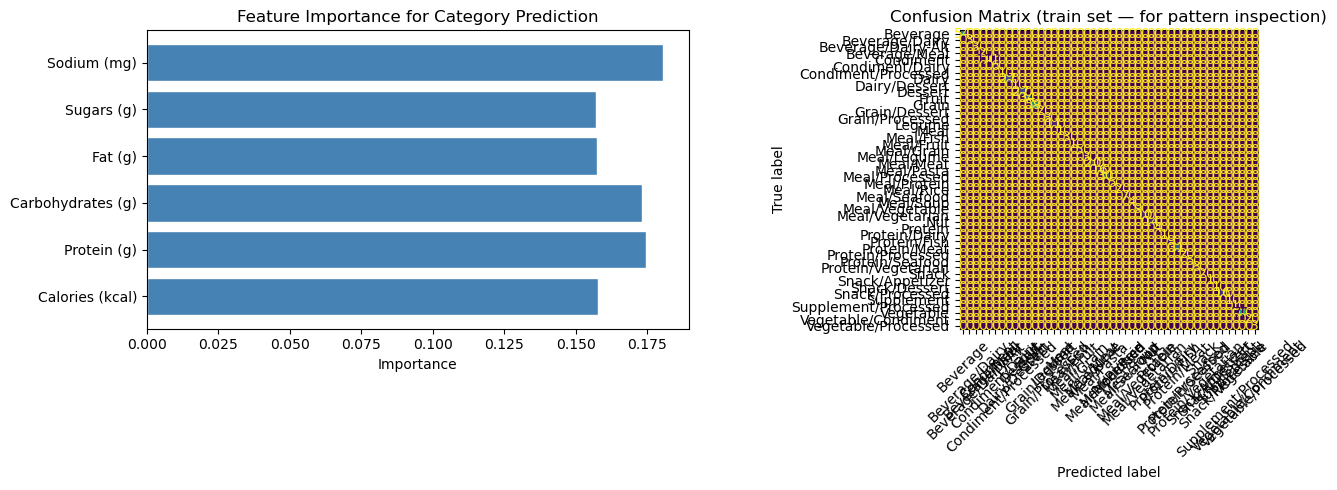


Per-class report (train):
                      precision    recall  f1-score   support

            Beverage       1.00      1.00      1.00        54
      Beverage/Dairy       1.00      1.00      1.00         3
  Beverage/Dairy-Alt       1.00      1.00      1.00         3
       Beverage/Meal       1.00      1.00      1.00         2
           Condiment       1.00      0.99      1.00       120
     Condiment/Dairy       0.86      1.00      0.92         6
 Condiment/Processed       1.00      1.00      1.00         1
               Dairy       1.00      1.00      1.00        27
       Dairy/Dessert       1.00      1.00      1.00         1
             Dessert       1.00      1.00      1.00        27
               Fruit       1.00      1.00      1.00        34
               Grain       1.00      1.00      1.00        59
       Grain/Dessert       1.00      1.00      1.00         2
     Grain/Processed       1.00      1.00      1.00         8
              Legume       1.00      1.00 

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prepare
df_clf = df[["Food_Item"] + nutrients].copy()
df_clf["Category"] = data["Category"]
df_clf = df_clf.dropna(subset=["Category"])

le = LabelEncoder()
y = le.fit_transform(df_clf["Category"])
X = scaler.fit_transform(df_clf[nutrients])

# 5-fold cross-validation
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")

print(f"Random Forest 5-fold CV Accuracy: {scores.mean():.1%} ± {scores.std():.1%}")
print(f"Per-fold: {[f'{s:.1%}' for s in scores]}")

# Feature importance
rf.fit(X, y)
importances = rf.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(nutrients, importances, color='steelblue', edgecolor='white')
axes[0].set_title("Feature Importance for Category Prediction")
axes[0].set_xlabel("Importance")

# Confusion matrix on full dataset (for visualization only)
y_pred = rf.predict(X)
ConfusionMatrixDisplay.from_predictions(
    y, y_pred, display_labels=le.classes_,
    ax=axes[1], colorbar=False, xticks_rotation=45
)
axes[1].set_title("Confusion Matrix (train set — for pattern inspection)")

plt.tight_layout()
plt.show()

print("\nPer-class report (train):")
print(classification_report(y, y_pred, target_names=le.classes_, zero_division=0))

In [18]:
# Interactive: predict category for a new food by entering its nutrient values
def predict_category(calories, protein, carbs, fat, sugars, sodium):
    """Predict food category from 6 nutrient values."""
    vec = scaler.transform([[calories, protein, carbs, fat, sugars, sodium]])
    pred = rf.predict(vec)[0]
    proba = rf.predict_proba(vec)[0]
    
    label = le.inverse_transform([pred])[0]
    top3 = sorted(zip(le.classes_, proba), key=lambda x: -x[1])[:3]
    
    print(f"Predicted category: '{label}'")
    print("Top-3 probabilities:")
    for cat, p in top3:
        bar = '█' * int(p * 30)
        print(f"  {cat:<20} {p:.1%}  {bar}")

# Test cases
print("=== Banana-like (high carb/sugar, low protein/fat) ===")
predict_category(calories=100, protein=1, carbs=26, fat=0.3, sugars=14, sodium=1)

print("\n=== Chicken-like (high protein, moderate fat) ===")
predict_category(calories=250, protein=30, carbs=0, fat=12, sugars=0, sodium=300)

print("\n=== Bread-like (high carb, low fat) ===")
predict_category(calories=80, protein=3, carbs=15, fat=1, sugars=2, sodium=140)

=== Banana-like (high carb/sugar, low protein/fat) ===
Predicted category: 'Fruit'
Top-3 probabilities:
  Fruit                88.5%  ██████████████████████████
  Beverage             2.5%  
  Condiment            2.0%  

=== Chicken-like (high protein, moderate fat) ===
Predicted category: 'Protein/Meat'
Top-3 probabilities:
  Protein/Meat         59.0%  █████████████████
  Meal/Meat            8.0%  ██
  Protein/Fish         6.5%  █

=== Bread-like (high carb, low fat) ===
Predicted category: 'Grain'
Top-3 probabilities:
  Grain                95.0%  ████████████████████████████
  Grain/Processed      1.5%  
  Meal/Vegetarian      1.0%  


## Feature 4: Meal Balancing — recommend items to hit daily targets

Given a partial meal and a patient's daily nutrient targets,
find the best single food item to add that brings the meal closest to the targets.

In [19]:
import numpy as np

# Typical daily targets (can be made patient-specific)
DAILY_TARGETS = {
    "Calories (kcal)":    2000,
    "Protein (g)":          50,
    "Carbohydrates (g)":   275,
    "Fat (g)":              78,
    "Sugars (g)":           50,
    "Sodium (mg)":        2300,
}

def balance_meal(current_meal_items: list[str], top_n: int = 5):
    """
    Given a list of food names already in the meal, recommend foods to add
    that best close the gap to daily targets.
    Score = negative euclidean distance in normalized nutrient space after adding the candidate.
    """
    target_vec = np.array([DAILY_TARGETS[n] for n in nutrients], dtype=float)
    
    # Sum nutrients already in the meal
    current_total = np.zeros(len(nutrients))
    print("Current meal:")
    for name in current_meal_items:
        match = df[df["Food_Item"].str.contains(name, case=False)]
        if match.empty:
            print(f"  [NOT FOUND] {name}")
            continue
        row = df_nutrients.iloc[match.index[0]].values
        current_total += row
        print(f"  + {df.iloc[match.index[0]]['Food_Item']}: {dict(zip([n.split()[0] for n in nutrients], row.round(1)))}")
    
    remaining = target_vec - current_total
    print(f"\nRemaining to hit daily targets:")
    for n, r in zip(nutrients, remaining):
        flag = " ← OVER" if r < 0 else ""
        print(f"  {n.split()[0]:<15} {r:+.1f}{flag}")
    
    # Score each candidate: how much does adding it reduce the gap?
    # Use normalized gap so all nutrients are on equal footing
    gap_norm = remaining / target_vec  # relative gap per nutrient
    
    scores = []
    for i, row in df_nutrients.iterrows():
        candidate = row.values
        # New gap after adding this item
        new_gap = gap_norm - (candidate / target_vec)
        # Lower L2 norm of remaining gap = better
        score = -np.linalg.norm(np.clip(new_gap, 0, None))  # only penalize deficit
        scores.append((score, i))
    
    scores.sort(reverse=True)
    
    print(f"\nTop {top_n} recommended foods to add:")
    print("-" * 65)
    for rank, (score, i) in enumerate(scores[:top_n], 1):
        name = df.iloc[i]["Food_Item"]
        vals = df_nutrients.iloc[i].round(1).to_dict()
        print(f"  {rank}. {name}")
        print(f"     {dict((k.split()[0], v) for k, v in vals.items())}")

# Example: breakfast already has eggs and toast
balance_meal(["Scrambled Eggs", "Whole Wheat Toast"], top_n=5)

Current meal:
  + Scrambled Eggs (2 large): {'Calories': np.float64(180.0), 'Protein': np.float64(12.0), 'Carbohydrates': np.float64(2.0), 'Fat': np.float64(14.0), 'Sugars': np.float64(1.0), 'Sodium': np.float64(180.0)}
  + Whole Wheat Toast (1 slice): {'Calories': np.float64(80.0), 'Protein': np.float64(4.0), 'Carbohydrates': np.float64(14.0), 'Fat': np.float64(1.0), 'Sugars': np.float64(2.0), 'Sodium': np.float64(140.0)}

Remaining to hit daily targets:
  Calories        +1740.0
  Protein         +34.0
  Carbohydrates   +259.0
  Fat             +63.0
  Sugars          +47.0
  Sodium          +1980.0

Top 5 recommended foods to add:
-----------------------------------------------------------------
  1. Chicken Parm Sandwich
     {'Calories': 650.0, 'Protein': 40.0, 'Carbohydrates': 55.0, 'Fat': 30.0, 'Sugars': 9.0, 'Sodium': 1400.0}
  2. Beef Burrito (large)
     {'Calories': 650.0, 'Protein': 30.0, 'Carbohydrates': 70.0, 'Fat': 28.0, 'Sugars': 5.0, 'Sodium': 1400.0}
  3. Meatball Sub

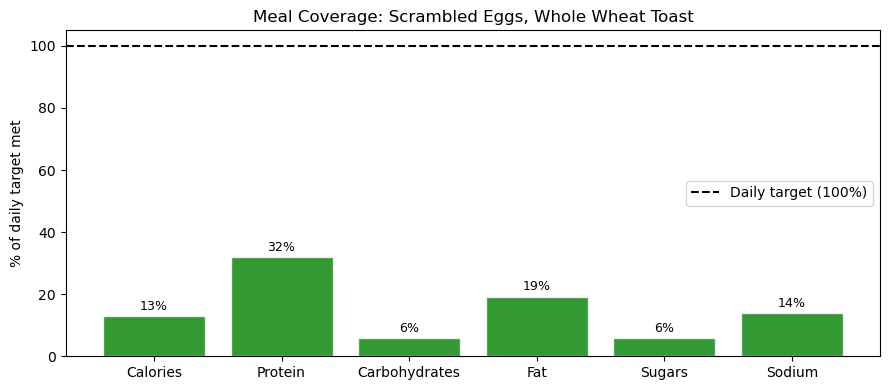

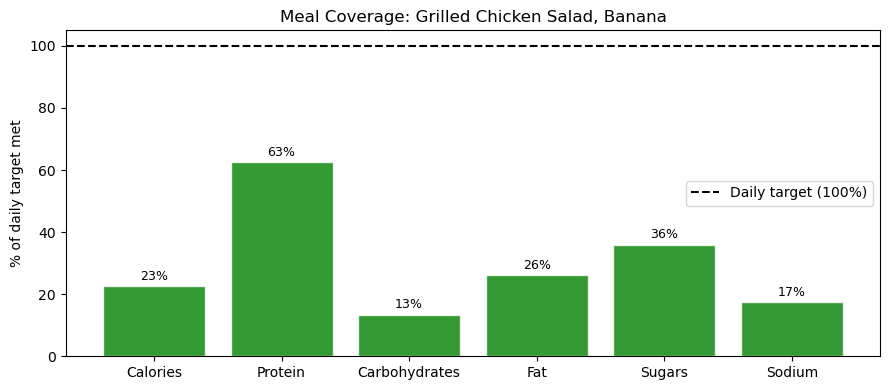

In [20]:
# Visualize the meal gap before/after adding the top recommendation
def plot_meal_gap(current_meal_items: list[str]):
    target_vec = np.array([DAILY_TARGETS[n] for n in nutrients], dtype=float)
    
    current_total = np.zeros(len(nutrients))
    for name in current_meal_items:
        match = df[df["Food_Item"].str.contains(name, case=False)]
        if not match.empty:
            current_total += df_nutrients.iloc[match.index[0]].values
    
    pct_of_target = (current_total / target_vec) * 100
    short_names = [n.split()[0] for n in nutrients]
    
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['green' if p <= 100 else 'red' for p in pct_of_target]
    bars = ax.bar(short_names, pct_of_target, color=colors, edgecolor='white', alpha=0.8)
    ax.axhline(100, color='black', linestyle='--', linewidth=1.5, label='Daily target (100%)')
    ax.set_ylabel("% of daily target met")
    ax.set_title(f"Meal Coverage: {', '.join(current_meal_items)}")
    ax.legend()
    
    for bar, pct in zip(bars, pct_of_target):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{pct:.0f}%", ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

plot_meal_gap(["Scrambled Eggs", "Whole Wheat Toast"])
plot_meal_gap(["Grilled Chicken Salad", "Banana"])